# Library comparisson with BitBirch

Authors: Kenneth Lopez-Perez (klopezperez@ufl.edu) and Ramon Miranda-Quintana (quintana@chem.ufl.edu)

This notebook shows examples on how to compare two libraries to identify regions of the chemical space they have in common, and what regions they do not share.


In [1]:
from iChem.libchem import LibChem, LibComparison
from iChem.visualization import *
import numpy as np
np.random.seed(42)

/home/kenneth/Documents/iChem/iChem/bblean/similarity.py:100: UserWarning: C++ optimized similarity calculations not available, falling back to python implementation
  warnings.warn(


Here we are going to create LibChem objects for each of the libraries we are going to compare. We are going to load the smiles and generate ECFP4 fingerprints to represent the molecules. 

We are going to compare mcule libraries. For download of this libraries please refer to https://mcule.com/database/.

In [2]:
Lib1 = LibChem()
Lib1.load_smiles('../tests/data/mcule_macrocycles.smi')
Lib1.generate_fingerprints(fp_type='ECFP4', n_bits=2048)

Lib2 = LibChem()
Lib2.load_smiles('../tests/data/mcule_natural_like_products.smi')
Lib2.generate_fingerprints(fp_type='ECFP4', n_bits=2048)

Lib3 = LibChem()
Lib3.load_smiles('../tests/data/mcule_natural_products_derivatives.smi')
Lib3.generate_fingerprints(fp_type='ECFP4', n_bits=2048)


Let's check the size of these libraries.

In [3]:
print('Library 1 molecules:', Lib1.n_molecules)
print('Library 2 molecules:', Lib2.n_molecules)
print('Library 3 molecules:', Lib3.n_molecules)

Library 1 molecules: 163427
Library 2 molecules: 178992
Library 3 molecules: 109173


Now, let's check the average similarity (iSIM) of each of these databases.

In [4]:
print(f'iSIM library 1: {Lib1.get_iSIM():.4f}')
print(f'iSIM library 2: {Lib2.get_iSIM():.4f}')
print(f'iSIM library 3: {Lib3.get_iSIM():.4f}')

iSIM library 1: 0.1714
iSIM library 2: 0.1126
iSIM library 3: 0.1284


Now, we are going to check the standard deviation of the similarities (iSIM-sigma).

In [5]:
print(f'iSIM-sigma library 1: {Lib1.get_iSIM_sigma():.4f}')
print(f'iSIM-sigma library 2: {Lib2.get_iSIM_sigma():.4f}')
print(f'iSIM-sigma library 3: {Lib3.get_iSIM_sigma():.4f}')

iSIM-sigma library 1: 0.0727
iSIM-sigma library 2: 0.0484
iSIM-sigma library 3: 0.0523


Now let's do the clustering of each of the libraries and get how many clusters each one has. Some considerations:

- Note that an automatic threshold is used if `None` is indicated, this is iSIM + 3.5 iSIM-sigma. User can use a different threshold if they want to, but it needs to be indicated. 

- The branching factor is set as default to 1024, if libraries are larger than 1 million, user might want to increase the branching factor to consume less memory and get better results. 

- A default reclustering is also set as default to recuperate some singletons that might've not been clustered because of the initial tree structure, this step uses an extrathreshold of one iSIM-sigma, to prevent the formation of low quality clusters. Users have the option of not doing the reclustering step.

In [6]:
Lib1.cluster(threshold=None,
             branching_factor=1024,
             recluster=True)
Lib2.cluster()
Lib3.cluster()

Let's check how many clusters were found. With the following method, one can get the fingerprints and SMILES of the medoids of each cluster. 

In [7]:
print('Number of medoids library 1:', len(Lib1.get_cluster_medoids(return_smiles=False)))
print('Number of medoids library 2:', len(Lib2.get_cluster_medoids(return_smiles=False)))
print('Number of medoids library 3:', len(Lib3.get_cluster_medoids(return_smiles=False)))

Number of medoids library 1: 1122
Number of medoids library 2: 5554
Number of medoids library 3: 2982


### Library comparison

Now we are going to compare the libraries that we created and clustered above. For this we are going to use the `LibComparison` class. First, we gotta add the libraries to the instance. 

In [8]:
CompLib = LibComparison()
CompLib.add_library(Lib1, 'Macrocycles')
CompLib.add_library(Lib2, 'LikeProducts')
CompLib.add_library(Lib3, 'Derivatives')

Now we are going to compare the medoids between each pair of libraries. We are going to do the pairwise comparisons between medoids of two libraries, and then get the maximum similarity for each one, and then get the average. The higher the value, the more similar the two libraries are.

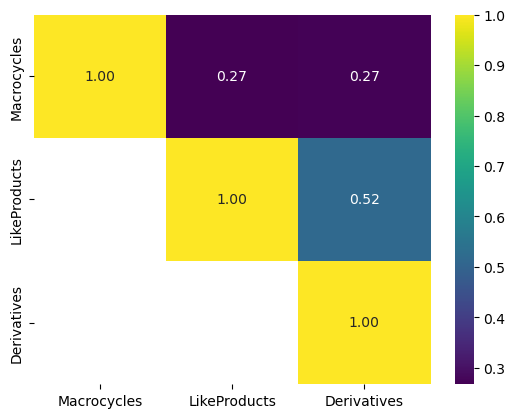

In [9]:
sims_results = CompLib.compare_medoids_heatmap(methodology='MaxSum')

As expected, the Natural-Like Products and the Natural Product Derivatives are more similar between each other than with the Macrocyles libraries.

Now, to address the comparison on a more local level, we are going to cluster the medoids from each library together. In this way we can get what sectors of chemical space they share and which are exclusive to one of the libraries.

To do the clustering, we will use the highest threshold of the individual libraries, to prevent the formation of lower quality clusters than the initial ones.

In [13]:
print(CompLib.libraries['Macrocycles'].threshold)
print(CompLib.libraries['LikeProducts'].threshold)
print(CompLib.libraries['Derivatives'].threshold)

0.42585043664120653
0.2818716636124799
0.3115604508755774


With the following method, we can get the counts and mapping of the different types of clusters in terms of membership of the libraries. One can indicate with lib_names which libraries are going to be compared. If not indicated, all the loaded libraries will be compared. 

In [28]:
counts, mapping = CompLib.cluster_classification_counts(methodology='medoids',
                                          lib_names=['Macrocycles','LikeProducts', 'Derivatives'], # One can indicate which 
                                          verbose=True)

Number of medoids in Library Macrocycles: 1122
Number of medoids in Library LikeProducts: 5554
Number of medoids in Library Derivatives: 2982
Total number of medoids: 9658
Using clustering threshold: 0.4259


In [29]:
counts

{'Macrocycles': 706,
 'Derivatives+LikeProducts': 1219,
 'LikeProducts+Macrocycles': 70,
 'Derivatives+LikeProducts+Macrocycles': 28,
 'LikeProducts': 3230,
 'Derivatives+Macrocycles': 21,
 'Derivatives': 1207}

The mapping gives you the cluster number that correspond to each catedory, so for example in the next cell we will see the clsuters that have molecules from Natural Products Derivatives and Macrocycles

In [30]:
mapping['Derivatives+Macrocycles']

[82,
 91,
 164,
 456,
 482,
 628,
 728,
 812,
 837,
 863,
 925,
 1110,
 1111,
 1118,
 1204,
 1280,
 1295,
 1305,
 1440,
 1595,
 1800]

We can analyze the compositon of the clusters, here we show a pie chart with the proportion by each of the categories. 

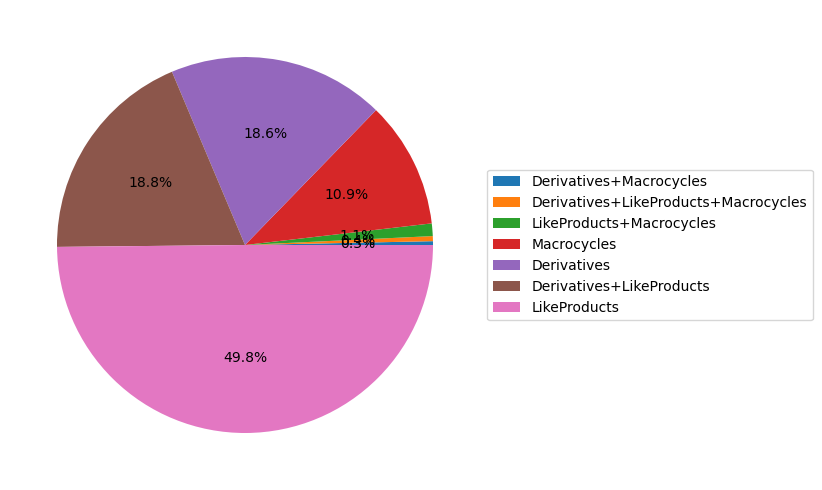

In [31]:
CompLib.pie_chart_composition()

Here we show the populations of each cluster color-coded by the membership of each library in each cluster. User can define the number of top clusters to include in the plot.

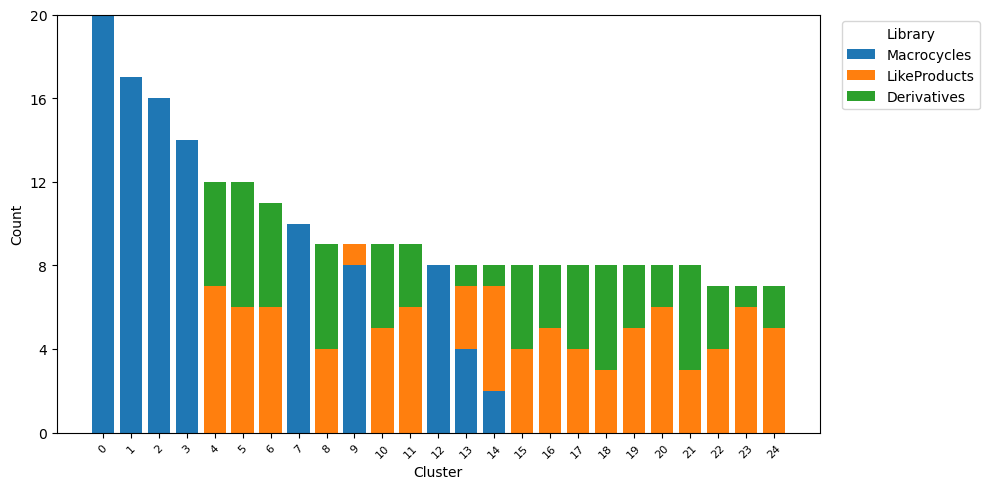

In [32]:
CompLib.plot_cluster_composition(lib_names=['Macrocycles','LikeProducts', 'Derivatives'],
                                 top=25)

We can also visualize to see if the clustering and chemical space comparison makes sense. For example, the largest cluster with molecules from the 3 libraries is cluster number 13, we can visualize the structures and see if they indeed correspond to a shared chemical space. (Cluster number may change due to randomization in the clustering of the combined libraries)

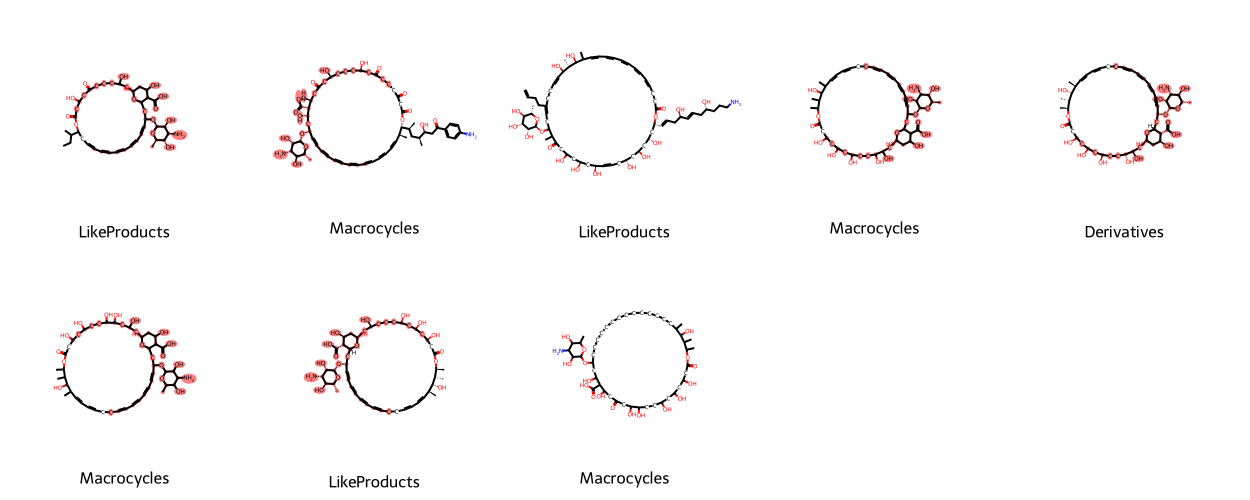

In [33]:
CompLib.cluster_visualization(cluster_number=13)

Now, let's inspect only clusters that have only molecules from one library. Let's check cluster 1.

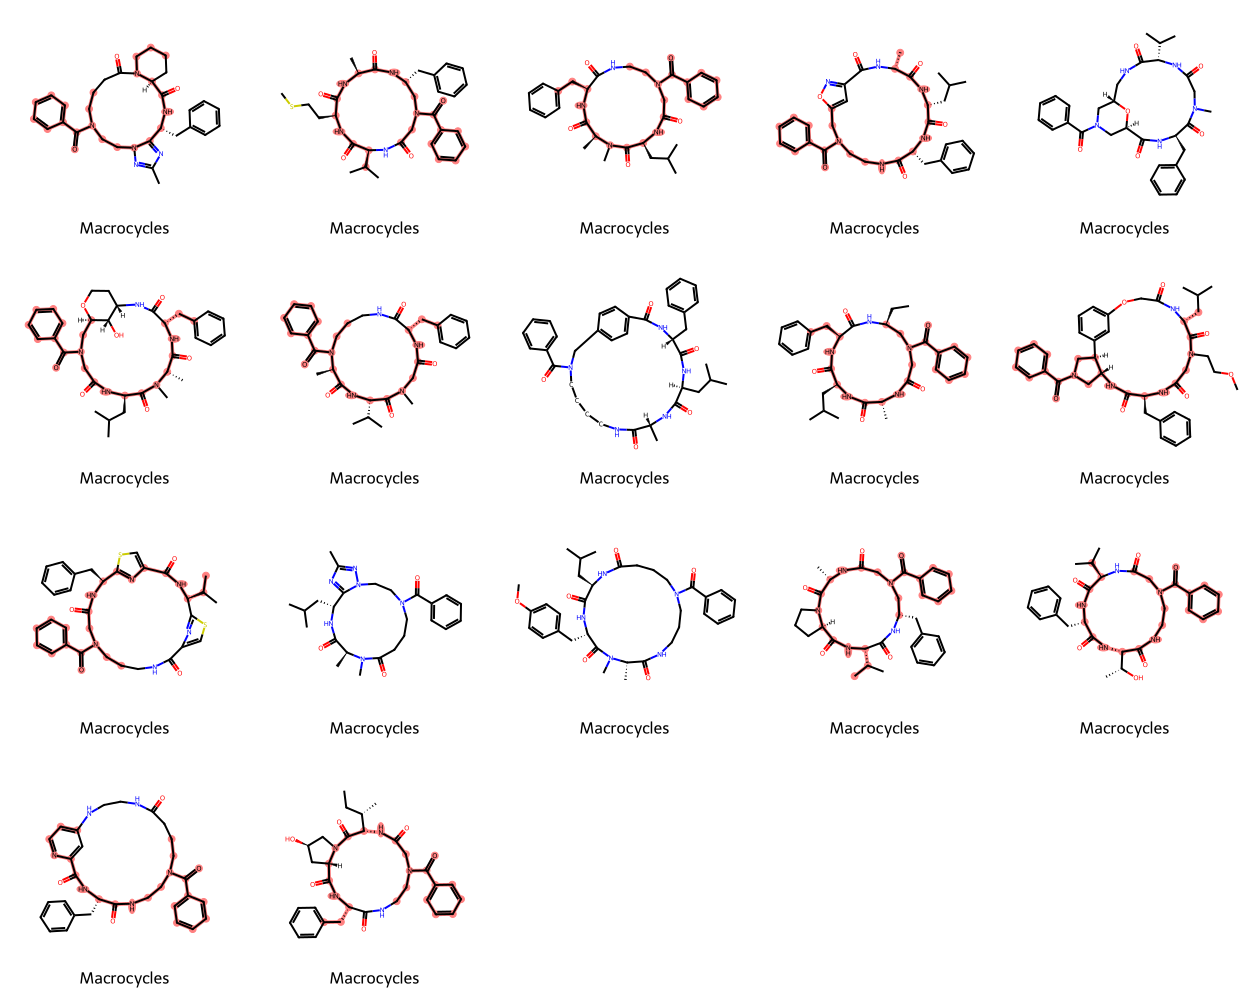

In [34]:
CompLib.cluster_visualization(cluster_number=1)

We can also compare certaing libraries and not all we added. We can compare the three possible pairs and see if we get similar results to when we do the three at the same time.

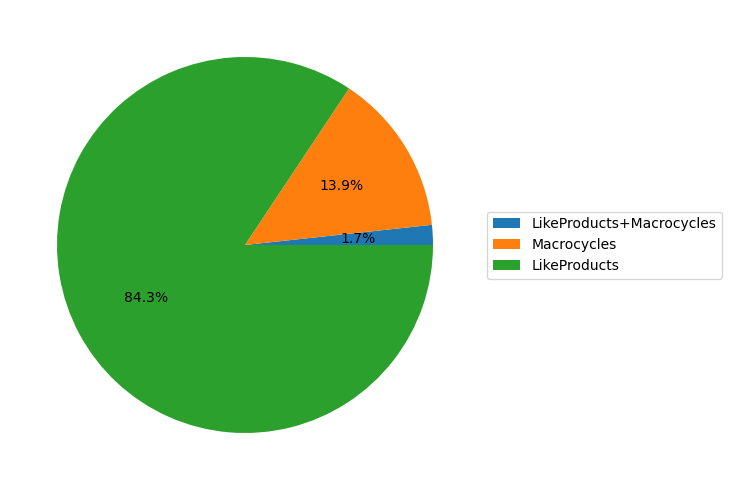

In [ ]:
CompLib.cluster_libraries(methodology='medoids',
                         lib_names=['Macrocycles','LikeProducts'])
CompLib.pie_chart_composition(lib_names=['Macrocycles','LikeProducts'])

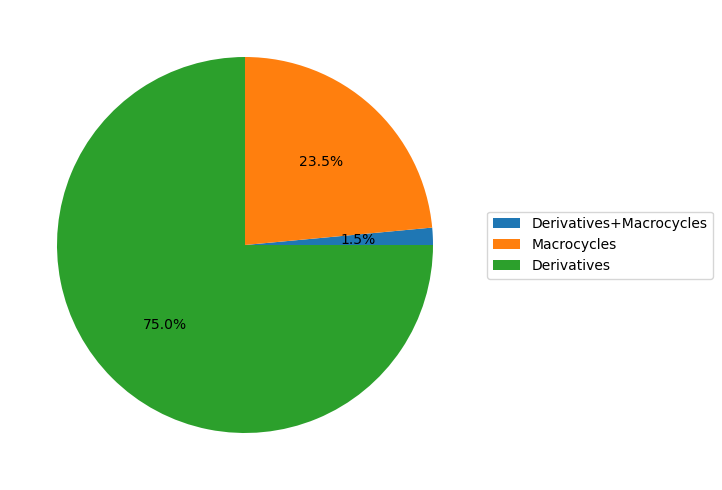

In [26]:
CompLib.cluster_libraries(methodology='medoids',
                         lib_names=['Macrocycles','Derivatives'])
CompLib.pie_chart_composition(lib_names=['Macrocycles','Derivatives'])

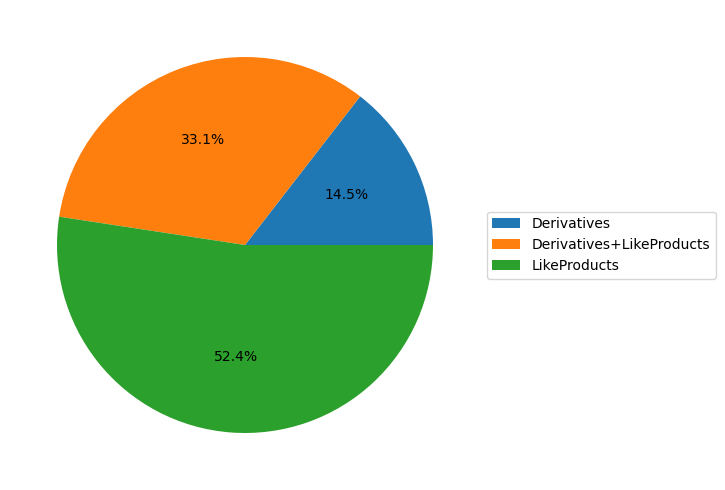

In [25]:
CompLib.cluster_libraries(methodology='medoids',
                         lib_names=['LikeProducts','Derivatives'])
CompLib.pie_chart_composition(lib_names=['LikeProducts','Derivatives'])